<a href="https://colab.research.google.com/github/nethra-prabhu/DLL/blob/main/Programs1-4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Program 1
import numpy as np
from tensorflow.keras import layers, models, optimizers

x = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0,1,1,0])

model = models.Sequential([
    layers.Input((2,)),
    layers.Dense(2, activation = 'relu'),
    layers.Dense(1, activation = 'sigmoid')
])

model.compile(optimizer=optimizers.Adam(0.01), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x, y, epochs=1000, verbose=0)

loss, acc = model.evaluate(x,y)
print(f'Accuracy: {acc*100:.2f}%')

pred = (model.predict(x) > 0.5).astype(int)
print('\nPredictions: ')
for xi, p, yi in zip(x, pred, y):
  print(f'Input: {xi} - Predcited Output: {p[0]} - True Output: {yi}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 1.0000 - loss: 0.0059
Accuracy: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Predictions: 
Input: [0 0] - Predcited Output: 0 - True Output: 0
Input: [0 1] - Predcited Output: 1 - True Output: 1
Input: [1 0] - Predcited Output: 1 - True Output: 1
Input: [1 1] - Predcited Output: 0 - True Output: 0


In [9]:
# Program 2
import numpy as np
from tensorflow.keras import datasets, callbacks, layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train = x_train[..., None] / 255
x_train = np.clip(x_train + 0.05 * np.random.normal(size=x_train.shape), 0, 1)

gen = ImageDataGenerator(rotation_range=10, width_shift_range=0.1, height_shift_range=0.1, validation_split=0.2)

model = models.Sequential([
    layers.Input((28,28,1)),
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l1_l2(1e-5, 1e-4)),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(gen.flow(x_train, y_train, batch_size=128, subset='training'),
          validation_data=gen.flow(x_train, y_train, batch_size=128, subset='validation'),
          epochs = 5,
          callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True)])

loss, acc = model.evaluate(x_test, y_test)
print(f'Accuracy: {acc:.4f}')

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.6665 - loss: 1.1408 - val_accuracy: 0.8842 - val_loss: 0.5208
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.8369 - loss: 0.6440 - val_accuracy: 0.9260 - val_loss: 0.3819
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.8674 - loss: 0.5474 - val_accuracy: 0.9340 - val_loss: 0.3503
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.8857 - loss: 0.4958 - val_accuracy: 0.9419 - val_loss: 0.3262
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.8958 - loss: 0.4660 - val_accuracy: 0.9509 - val_loss: 0.2972
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9654 - loss: 16.2085
Accuracy: 0.9654


/tmp/ipykernel_2463/4048636659.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Final Loss (SGD): 0.015679
Final Loss (Momentum): 0.001001
Final Loss (Adam): 0.000019


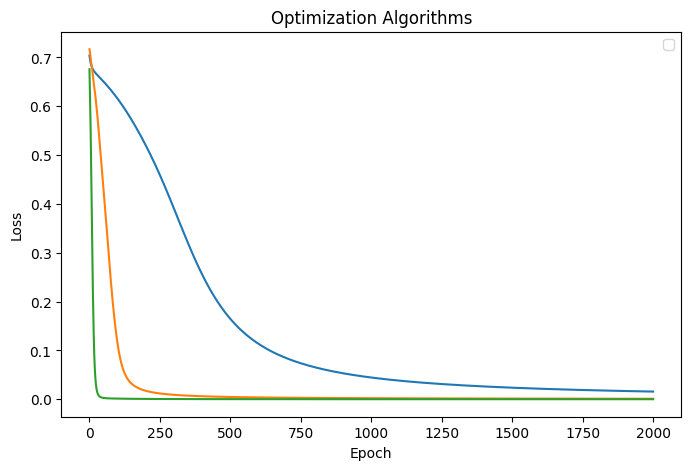

In [12]:
# Program 3
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers

x = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

def train(opt):
  model = models.Sequential([
    layers.Input((2,)),
    layers.Dense(4, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
  ])
  model.compile(optimizer=opt, loss='binary_crossentropy')
  return model.fit(x, y, epochs=2000, verbose=0).history['loss']

losses = {
    'SGD': train(optimizers.SGD(0.1)),
    'Momentum': train(optimizers.SGD(0.1, momentum=0.9)),
    'Adam': train(optimizers.Adam(0.1))
}

plt.figure(figsize=(8,5))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Optimization Algorithms')
for name, loss in losses.items():
  plt.plot(loss, label=name)

for name, loss in losses.items():
  print(f'Final Loss ({name}): {loss[-1]:.6f}')

plt.show()

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.9465 - loss: 0.1799 - val_accuracy: 0.9835 - val_loss: 0.0588
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.9842 - loss: 0.0536 - val_accuracy: 0.9885 - val_loss: 0.0390
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9889 - loss: 0.0371 - val_accuracy: 0.9875 - val_loss: 0.0393
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9905 - loss: 0.0298 - val_accuracy: 0.9873 - val_loss: 0.0436
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9930 - loss: 0.0217 - val_accuracy: 0.9918 - val_loss: 0.0326
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9892 - loss: 0.0342
Test Accuracy: 0.9892


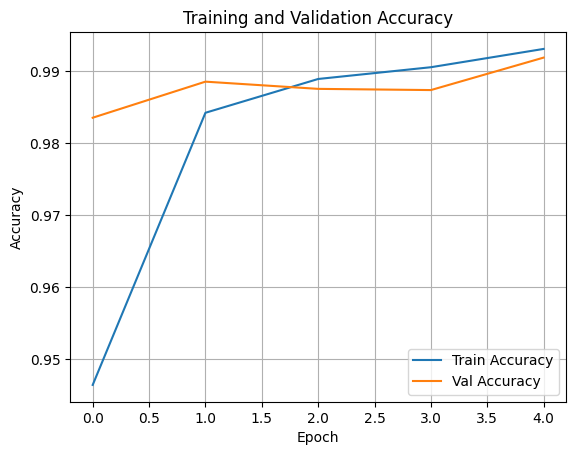

In [13]:
# program 4
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, datasets

(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train, x_test = x_train[..., None] / 255, x_test[..., None] / 255

model = models.Sequential([
    layers.Input((28,28,1)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

loss, acc = model.evaluate(x_test, y_test)
print(f'Test Accuracy: {acc:.4f}')

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()